# 🔗 Malicious URL Classification
### Mini Project: Machine Learning Application

| | |
|---|---|
| **สมาชิกกลุ่ม** | 1. ............................ 2. ............................ 3. ............................ |
| **โจทย์** | จำแนก URL เป็น 4 ประเภท: `benign` · `defacement` · `phishing` · `malware` |
| **ประเภทงาน** | Supervised Learning — Multiclass **Classification** |
| **Dataset** | Malicious URLs Dataset (Kaggle) — 651,191 URLs |
| **โมเดลที่เปรียบเทียบ** | 7 โมเดล + Baseline (scikit-learn ทั้งหมด) |
| **Web App** | Streamlit (`app.py`) |

**สารบัญ**
1. Problem Definition
2. Dataset
3. Data Preprocessing
4. Machine Learning Models (เปรียบเทียบ 7 โมเดล)
5. Model Evaluation
6. Web Application
7. Discussion
8. References

> ⏱️ รันทั้ง Notebook บน Google Colab (CPU) ใช้เวลาประมาณ 20–30 นาที ถ้าต้องการทดสอบเร็ว ให้ตั้ง `QUICK_RUN = True` (ใช้ข้อมูล 100,000 แถว)

## ⚙️ Setup — ติดตั้งไลบรารีและตั้งค่า

In [1]:
# ติดตั้งแพ็กเกจที่ Colab ไม่มีมาให้ (ถ้ามีแล้วจะข้ามไป)
import importlib.util, subprocess, sys
for pkg in ["kagglehub"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

In [2]:
import time, warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy import sparse

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer, MaxAbsScaler
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_selection import f_classif
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
QUICK_RUN = False            # True = ใช้ข้อมูล 100,000 แถวเพื่อทดสอบเร็ว
LABELS = ["benign", "defacement", "phishing", "malware"]
COLORS = {"benign": "#4C78A8", "defacement": "#9D72B8", "phishing": "#F28E2B", "malware": "#E15759"}
Path("models").mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.titleweight": "bold"})
pd.set_option("display.float_format", "{:.4f}".format)

def defang(url, n=90):
    """แสดง URL แบบกดไม่ได้ (hxxp, [.]) เพื่อความปลอดภัย"""
    s = str(url)[:n]
    return s.replace("http", "hxxp").replace(".", "[.]")

---
# 1. Problem Definition

### ปัญหาที่ต้องการแก้ไข
ผู้ใช้อินเทอร์เน็ตได้รับลิงก์จำนวนมากจากอีเมล แชต และโซเชียลมีเดีย ลิงก์บางส่วนเป็น **phishing** (หลอกขโมยรหัสผ่าน/ข้อมูลบัญชี)
หรือ **malware** (หลอกให้ดาวน์โหลดโปรแกรมอันตราย) โครงงานนี้สร้างโมเดลที่ **อ่านเฉพาะข้อความ URL** แล้วจำแนกว่าเป็นลิงก์ประเภทใด
เพื่อช่วยคัดกรองลิงก์ก่อนผู้ใช้กดเปิด

### เหตุผลที่เลือกปัญหา
- Phishing เป็นภัยไซเบอร์ที่พบบ่อยที่สุดประเภทหนึ่ง และความเสียหายเกิดทันทีที่ผู้ใช้กดลิงก์
- การดูจากข้อความ URL **ทำได้เร็วและปลอดภัย** เพราะไม่ต้องเปิดเว็บไซต์จริง
- Blacklist ตามไม่ทันลิงก์ใหม่ แต่ ML สามารถเรียนรู้ **รูปแบบ** ของ URL อันตรายได้

### ประเภทของ Machine Learning
**Supervised Learning → Multiclass Classification** เพราะข้อมูลมีคำตอบ (label) กำกับ และคำตอบเป็น **หมวดหมู่ 4 ค่า** ไม่ใช่ตัวเลขต่อเนื่อง
(ถ้าเป็นการทำนายค่าตัวเลข เช่น ราคา จะเป็น Regression)

| Target (`type`) | ความหมาย |
|---|---|
| 🟦 **benign** | URL ปกติ ปลอดภัย |
| 🟪 **defacement** | URL ของเว็บไซต์ที่ถูกแฮ็กและเปลี่ยนเนื้อหา |
| 🟧 **phishing** | URL หลอกให้กรอกรหัสผ่าน/ข้อมูลส่วนตัว |
| 🟥 **malware** | URL ที่แจกจ่ายหรือติดตั้งมัลแวร์ |

---
# 2. Dataset

| หัวข้อ | รายละเอียด |
|---|---|
| **แหล่งที่มา** | Kaggle — [Malicious URLs Dataset](https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset) โดย Manu Siddhartha (รวบรวมจาก ISCX-URL2016, PhishTank, PhishStorm, Malware Domain Blacklist) |
| **ไฟล์** | `malicious_phish.csv` |
| **จำนวนข้อมูล** | 651,191 แถว × 2 คอลัมน์ |
| **Feature (X)** | `url` — ข้อความ URL (จะแปลงเป็น TF-IDF + lexical features 27 ตัวในขั้น Preprocessing) |
| **Target (y)** | `type` — benign / defacement / phishing / malware |

In [3]:
# โหลด Dataset: ใช้ไฟล์ในเครื่องถ้ามี ไม่เช่นนั้นดาวน์โหลดจาก Kaggle ผ่าน kagglehub
candidates = [Path("data/malicious_phish.csv"), Path("malicious_phish.csv"), Path("/content/malicious_phish.csv")]
csv_path = next((p for p in candidates if p.is_file()), None)
if csv_path is None:
    import kagglehub
    folder = Path(kagglehub.dataset_download("sid321axn/malicious-urls-dataset/versions/1"))
    csv_path = folder / "malicious_phish.csv"

raw = pd.read_csv(csv_path)
print(f"ไฟล์: {csv_path}")
print(f"ขนาดข้อมูล: {raw.shape[0]:,} แถว × {raw.shape[1]} คอลัมน์")
raw.head(8).assign(url=lambda d: d.url.map(defang))

ไฟล์: data\malicious_phish.csv
ขนาดข้อมูล: 651,191 แถว × 2 คอลัมน์


,url,type
0,br-icloud[.]com[.]br,phishing
1,mp3raid[.]com/music/krizz_kaliko[.]html,benign
2,bopsecrets[.]org/rexroth/cr/1[.]htm,benign
3,hxxp://www[.]garage-pirenne[.]be/index[.]php?o...,defacement
4,hxxp://adventure-nicaragua[.]net/index[.]php?o...,defacement
5,hxxp://buzzfil[.]net/m/show-art/ils-etaient-lo...,benign
6,espn[.]go[.]com/nba/player/_/id/3457/brandon-rush,benign
7,yourbittorrent[.]com/?q=anthony-hamilton-soulife,benign


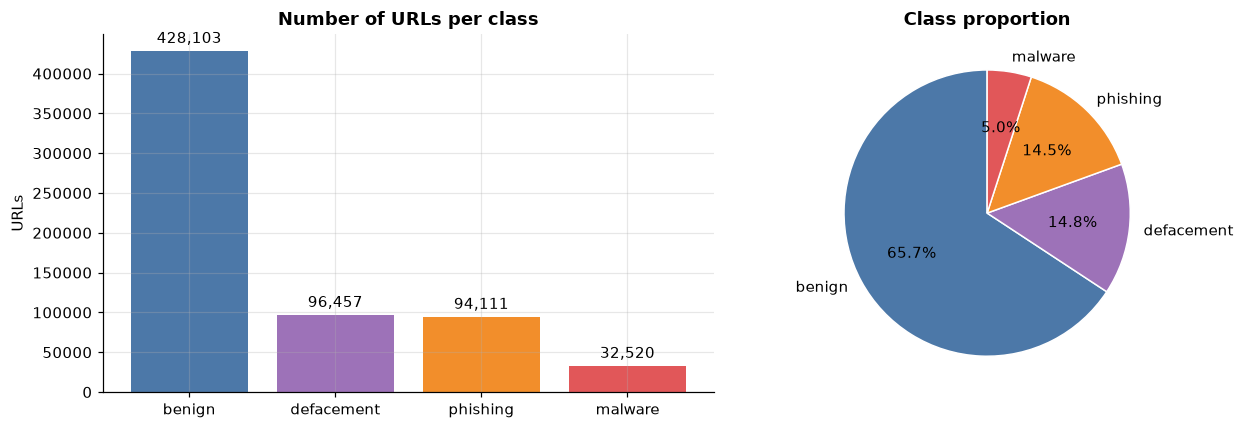

In [4]:
class_counts = raw["type"].value_counts().reindex(LABELS)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bars = ax[0].bar(class_counts.index, class_counts.values, color=[COLORS[c] for c in LABELS])
ax[0].bar_label(bars, labels=[f"{v:,}" for v in class_counts.values], padding=3)
ax[0].set_title("Number of URLs per class"); ax[0].set_ylabel("URLs")
ax[1].pie(class_counts.values, labels=LABELS, autopct="%1.1f%%", startangle=90,
          colors=[COLORS[c] for c in LABELS], wedgeprops={"edgecolor": "white"})
ax[1].set_title("Class proportion")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** ข้อมูลไม่สมดุล (**Imbalanced**) — `benign` มีประมาณ 66% ส่วน `malware` มีเพียงประมาณ 5%
ถ้าวัดผลด้วย Accuracy อย่างเดียว โมเดลที่ทายว่า "benign" ทุกครั้งก็ได้ Accuracy ~66% แล้ว
จึงต้องใช้ **Macro F1** และ **Recall รายคลาส** เป็นเกณฑ์หลัก และใช้ `class_weight="balanced"` ตอนฝึก

---
# 3. Data Preprocessing

ขั้นตอนทั้งหมดในส่วนนี้:

| # | ขั้นตอน | วิธีที่ใช้ |
|---|---|---|
| 3.1 | Missing Value | ตรวจ `isna()` |
| 3.2 | Duplicate & Label Conflict | ลบแถวซ้ำ และลบ URL ที่มีหลาย label |
| 3.3 | ข้อความเสียหาย | ตัดช่องว่างหัวท้าย ลบ control characters |
| 3.4 | สำรวจข้อมูล (EDA) | ความยาว URL แยกตามคลาส |
| 3.5 | Train/Test Split | แบ่ง 80:20 แบบแยก hostname (ป้องกัน data leakage) |
| 3.6 | Feature Extraction / Encoding | Character TF-IDF + Lexical features 27 ตัว |
| 3.7 | Scaling | MaxAbsScaler |
| 3.8 | Feature Selection | จำกัด vocabulary TF-IDF + วัดความสำคัญ lexical features ด้วย ANOVA F-test |
| 3.9 | Imbalanced Data | `class_weight="balanced"` |

## 3.1 Missing Value

In [5]:
missing = pd.DataFrame({"dtype": raw.dtypes.astype(str),
                        "missing": raw.isna().sum(),
                        "empty_string": (raw.astype(str).apply(lambda s: s.str.strip().eq(""))).sum()})
missing

,dtype,missing,empty_string
url,str,0,0
type,str,0,0


**📊 ผลลัพธ์:** ไม่มี Missing Value และไม่มีข้อความว่าง จึง **ไม่ต้องทำ imputation**

## 3.2 Duplicate และ Label Conflict
- **Exact duplicate** = URL และ label เหมือนกันทุกตัวอักษร → เก็บไว้แถวเดียว (ถ้าไม่ลบ URL เดียวกันอาจอยู่ทั้งใน Train และ Test ทำให้คะแนนสูงเกินจริง)
- **Label conflict** = URL เดียวกันแต่มี label ต่างกัน → ลบทุกแถวของ URL นั้น เพราะไม่รู้ว่า label ไหนถูก

## 3.3 ข้อความเสียหาย
- ตัดช่องว่างหัว/ท้าย (`strip`) และแปลง label เป็นตัวพิมพ์เล็ก
- ลบ URL ที่มี **control characters** (เช่น `\x00`, `\x07`) ซึ่งไม่ใช่ URL ที่พิมพ์ได้จริง

ตัวอย่าง URL ที่มี label ขัดแย้งกัน:


,url,type
328665,ebookstore[.]sony[.]com/reader/,benign
616942,ebookstore[.]sony[.]com/reader/,phishing
259609,en[.]wikipedia[.]org/wiki/Desktop_publishing,benign
616832,en[.]wikipedia[.]org/wiki/Desktop_publishing,phishing
213051,en[.]wikipedia[.]org/wiki/E-book,benign
616866,en[.]wikipedia[.]org/wiki/E-book,phishing


,rows
raw_rows,651191
exact_duplicates,10066
label_conflict_rows,12
control_char_rows,102
clean_rows,641011


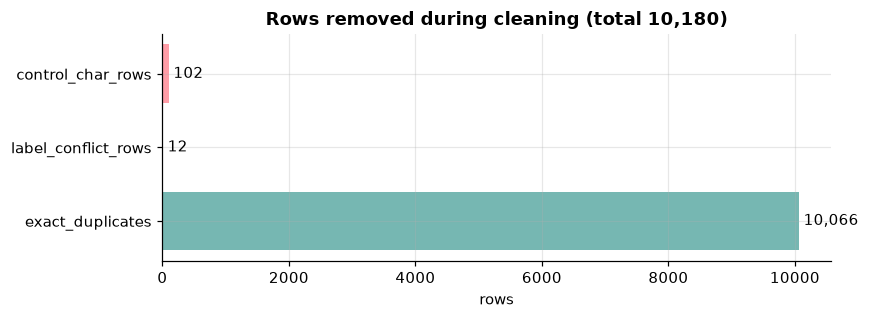

In [6]:
CONTROL_PATTERN = r"[\x00-\x1F\x7F-\x9F]"
audit = {"raw_rows": len(raw)}

df = raw[["url", "type"]].copy()
df["url"] = df["url"].astype(str).str.strip()
df["type"] = df["type"].astype(str).str.strip().str.lower()

# 3.2 Exact duplicates
audit["exact_duplicates"] = int(df.duplicated(["url", "type"]).sum())
df = df.drop_duplicates(["url", "type"])

# 3.2 Label conflicts
n_labels = df.groupby("url")["type"].transform("nunique")
audit["label_conflict_rows"] = int((n_labels > 1).sum())
print("ตัวอย่าง URL ที่มี label ขัดแย้งกัน:")
display(df[n_labels > 1].sort_values("url").head(6).assign(url=lambda d: d.url.map(defang)))
df = df[n_labels == 1]

# 3.3 Control characters
has_control = df["url"].str.contains(CONTROL_PATTERN, regex=True)
audit["control_char_rows"] = int(has_control.sum())
df = df[~has_control].reset_index(drop=True)
audit["clean_rows"] = len(df)

if QUICK_RUN:
    df = df.groupby("type", group_keys=False).sample(frac=100_000 / len(df), random_state=RANDOM_STATE).reset_index(drop=True)

audit_s = pd.Series(audit)
display(audit_s.to_frame("rows"))

fig, ax = plt.subplots(figsize=(8, 3))
removed = audit_s[["exact_duplicates", "label_conflict_rows", "control_char_rows"]]
bars = ax.barh(removed.index, removed.values, color=["#76B7B2", "#EDC948", "#FF9DA7"])
ax.bar_label(bars, labels=[f"{v:,}" for v in removed.values], padding=3)
ax.set_title(f"Rows removed during cleaning (total {removed.sum():,})"); ax.set_xlabel("rows")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** ลบ exact duplicate ~10,066 แถว, label conflict 12 แถว และ control characters ~102 แถว
เหลือข้อมูลสะอาด **641,011 แถว** (ลดลงเพียง ~1.6%)

## 3.4 สำรวจข้อมูล (EDA): ความยาว URL แยกตามคลาส

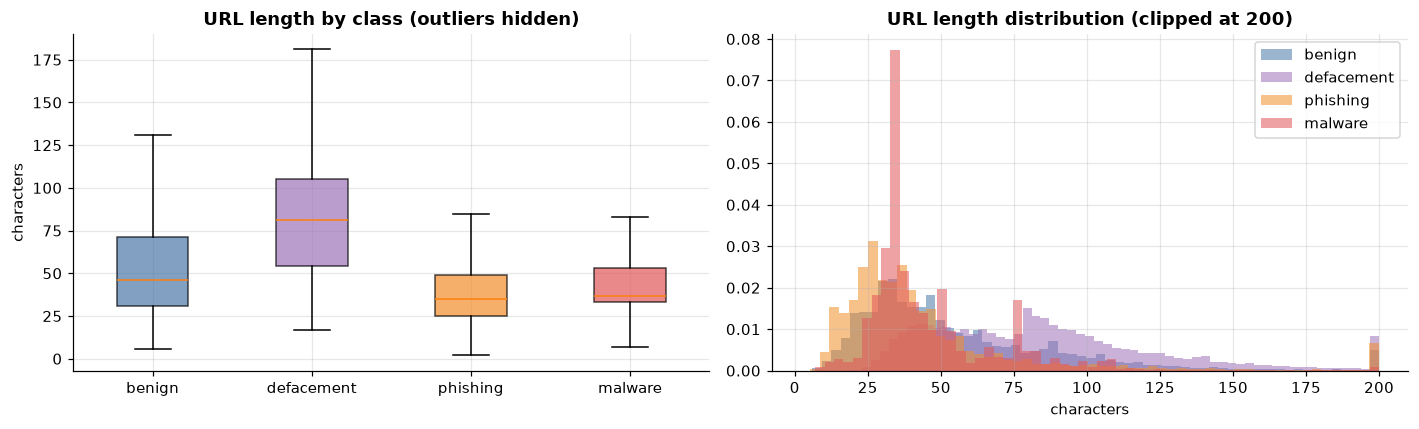

,mean,50%,min,max
type,,,,
benign,57.6754,46.0000,6.0000,2175.0000
defacement,86.1284,81.0000,17.0000,327.0000
phishing,45.7840,35.0000,2.0000,1779.0000
malware,46.6103,37.0000,7.0000,378.0000


In [7]:
df["url_length"] = df["url"].str.len()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
data = [df.loc[df.type == c, "url_length"] for c in LABELS]
bp = ax[0].boxplot(data, tick_labels=LABELS, showfliers=False, patch_artist=True)
for patch, c in zip(bp["boxes"], LABELS):
    patch.set_facecolor(COLORS[c]); patch.set_alpha(0.7)
ax[0].set_title("URL length by class (outliers hidden)"); ax[0].set_ylabel("characters")
for c in LABELS:
    ax[1].hist(df.loc[df.type == c, "url_length"].clip(upper=200), bins=60, alpha=0.55,
               label=c, color=COLORS[c], density=True)
ax[1].set_title("URL length distribution (clipped at 200)"); ax[1].set_xlabel("characters"); ax[1].legend()
plt.tight_layout(); plt.show()
df.groupby("type")["url_length"].describe().reindex(LABELS)[["mean", "50%", "min", "max"]]

**📊 ผลลัพธ์:** `defacement` ยาวที่สุด (median 81 ตัวอักษร เพราะมี path/query ยาวของ CMS เช่น `index.php?option=...`)
ส่วน `phishing` และ `malware` สั้นที่สุด (median ~35–37) ความยาวจึงเป็นสัญญาณที่มีประโยชน์ แต่กราฟซ้อนทับกันมาก
ใช้ความยาวอย่างเดียวแยกคลาสไม่ได้ ต้องใช้ features อื่นร่วมด้วย

### รูปแบบการเขียน URL แยกตามคลาส (มี `http(s)://` / `www.` หรือไม่)

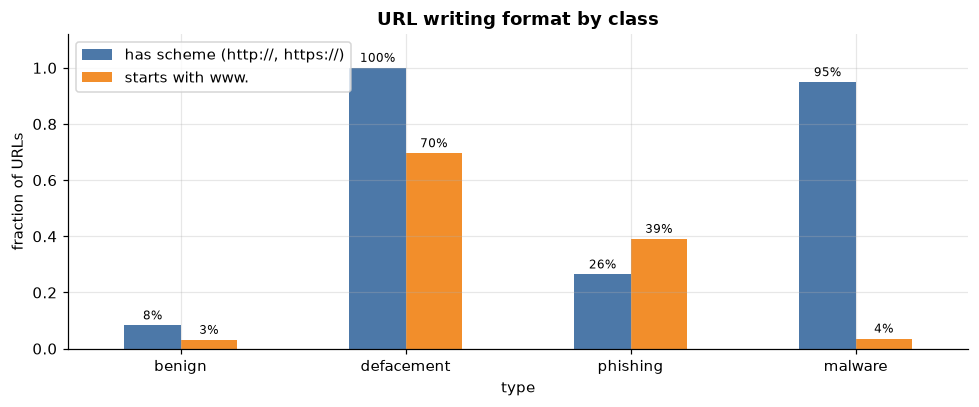

In [8]:
fmt = pd.DataFrame({
    "has scheme (http://, https://)": df["url"].str.match(r"^[A-Za-z][A-Za-z0-9+.-]*://"),
    "starts with www.": df["url"].str.contains(r"^(?:[A-Za-z]+://)?www\d?\.", case=False, regex=True),
}).groupby(df["type"]).mean().reindex(LABELS)
ax = fmt.plot.bar(figsize=(9, 3.8), rot=0, color=["#4C78A8", "#F28E2B"])
for c in ax.containers:
    ax.bar_label(c, labels=[f"{v*100:.0f}%" for v in c.datavalues], fontsize=8, padding=2)
ax.set_ylim(0, 1.12); ax.set_ylabel("fraction of URLs"); ax.set_title("URL writing format by class")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์ (สำคัญ):** รูปแบบการเขียน URL ต่างกันมากตาม **แหล่งที่เก็บข้อมูล** ไม่ใช่ตามความอันตราย —
`defacement` มี `http://` **100%**, `malware` ~95% แต่ `benign` มีเพียง ~8% ส่วน `www.` พบใน phishing ~39% แต่ benign เพียง ~3%
โมเดลจึงอาจเรียนรู้ "ทางลัด" นี้ได้ (เช่น เห็น `https://www.` แล้วคิดว่าอันตราย) — จะตรวจผลกระทบในหัวข้อ 5.6 และอภิปรายในหัวข้อ 7

**Outlier:** URL ยาวมาก (สูงสุด ~2,000 ตัวอักษร) **ไม่ลบทิ้ง** เพราะ URL ยาวผิดปกติเป็นลักษณะหนึ่งของ URL อันตราย

## 3.5 Train/Test Split (ทำก่อนสร้าง features เพื่อไม่ให้ข้อมูล Test รั่วเข้าการ fit)
ถ้าสุ่มแบ่งธรรมดา URL หลายรายการจากเว็บเดียวกัน (hostname เดียวกัน) จะไปอยู่ทั้ง Train และ Test
โมเดลจะ "จำชื่อเว็บ" แทนการเรียนรูปแบบ → คะแนนสูงเกินจริง (**data leakage**)
จึงใช้ **StratifiedGroupKFold** โดยให้ `group = hostname` และรักษาสัดส่วนคลาสใกล้เดิม แล้วใช้ 1 fold เป็น Test (≈20%)

Train: 512,808 แถว (80.0%)  |  Test: 128,203 แถว (20.0%)


hostname ที่ซ้ำกันระหว่าง Train/Test: 0


URL ที่ซ้ำกันระหว่าง Train/Test: 0


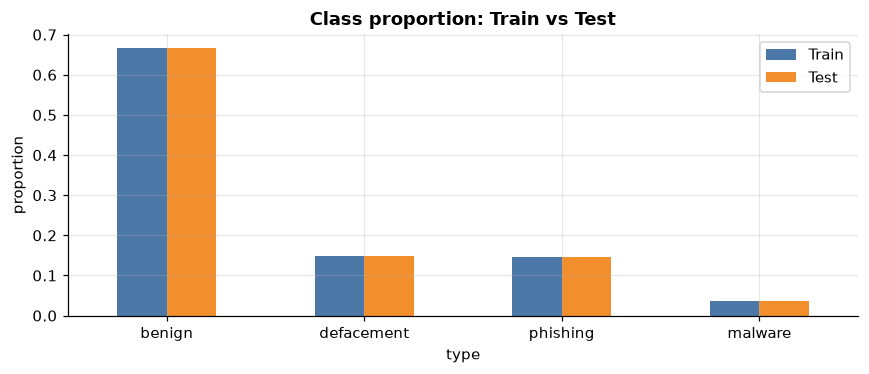

In [9]:
from urllib.parse import urlsplit
def get_host(u):
    try:
        return (urlsplit(u if re.match(r"^[A-Za-z][A-Za-z0-9+.-]*://", u) else "http://" + u).hostname or "").lower()
    except ValueError:
        return ""
df["host"] = df["url"].map(get_host)
groups = df["host"].where(df["host"] != "", "row_" + df.index.astype(str))

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(df["url"], df["type"], groups))
train, test = df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)
X_train_text, y_train = train["url"].to_numpy(dtype=object), train["type"].to_numpy()
X_test_text,  y_test  = test["url"].to_numpy(dtype=object),  test["type"].to_numpy()

print(f"Train: {len(train):,} แถว ({len(train)/len(df):.1%})  |  Test: {len(test):,} แถว ({len(test)/len(df):.1%})")
print(f"hostname ที่ซ้ำกันระหว่าง Train/Test: {len(set(train.host) & set(test.host) - {''})}")
print(f"URL ที่ซ้ำกันระหว่าง Train/Test: {len(set(train.url) & set(test.url))}")

prop = pd.DataFrame({"Train": train.type.value_counts(normalize=True),
                     "Test": test.type.value_counts(normalize=True)}).reindex(LABELS)
ax = prop.plot.bar(figsize=(8, 3.5), color=["#4C78A8", "#F28E2B"], rot=0)
ax.set_title("Class proportion: Train vs Test"); ax.set_ylabel("proportion")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** ได้ Train ≈ 80% / Test ≈ 20% สัดส่วนคลาสสองชุดใกล้กันมาก และ **hostname/URL ซ้ำกันระหว่าง Train–Test = 0**

## 3.6 Feature Extraction / Encoding
URL เป็น **ข้อความ** โมเดลต้องการตัวเลข จึงแปลงเป็น 2 กลุ่ม features:

**(A) Character TF-IDF** — ตัด URL เป็นชิ้นตัวอักษรยาว 3–5 ตัว (char n-grams) เช่น `paypal-login` → `pay`, `ayp`, `ypa`, ..., `login`
แล้วให้น้ำหนักด้วย TF-IDF (ชิ้นที่พบบ่อยในบาง URL แต่ไม่พบทั่วไปจะมีน้ำหนักสูง) ใช้ `max_features=50,000`

**(B) Lexical features 27 ตัว** — ตัวเลขที่สรุปโครงสร้างของ URL เช่น ความยาว, จำนวนตัวเลข, จำนวนจุด, มี IP แทนชื่อโดเมนไหม, มีคำว่า login/verify ไหม, entropy

Target (`type`) เป็นข้อความ 4 ค่า — scikit-learn classifiers รับ label เป็น string ได้โดยตรงและ encode ภายในให้ จึงไม่ต้องทำ LabelEncoder เอง

โค้ดสร้าง lexical features เขียนเป็นไฟล์ `url_features.py` เพื่อให้ **Notebook และ Web App ใช้โค้ดเดียวกัน**:

In [10]:
%%writefile url_features.py
"""แปลงข้อความ URL เป็น lexical features 27 ตัว (ใช้ร่วมกันทั้ง Notebook และ Web App)

ฟังก์ชันในไฟล์นี้อ่านเฉพาะ "ข้อความ" ของ URL เท่านั้น ไม่มีการเปิดเว็บไซต์หรือค้น DNS
"""
from __future__ import annotations

import ipaddress
import math
import re
from collections import Counter
from urllib.parse import urlsplit

import numpy as np

SCHEME_PATTERN = r"^[A-Za-z][A-Za-z0-9+.-]*://"
CONTROL_PATTERN = r"[\x00-\x1F\x7F-\x9F]"

SUSPICIOUS_WORDS = (
    "login", "signin", "verify", "secure", "account", "update", "bank",
    "password", "confirm", "wallet", "paypal", "invoice", "webscr",
)
SHORTENERS = {
    "bit.ly", "tinyurl.com", "t.co", "goo.gl", "ow.ly", "is.gd",
    "buff.ly", "adf.ly", "cutt.ly", "tiny.cc",
}

FEATURE_NAMES = [
    "url_length", "host_length", "path_length", "query_length", "fragment_length",
    "subdomain_count", "path_depth", "query_param_count", "digit_count", "alpha_count",
    "special_count", "dot_count", "hyphen_count", "slash_count", "at_count", "percent_count",
    "equals_count", "underscore_count", "is_https", "host_is_ip", "has_port", "punycode",
    "non_ascii", "known_shortener", "suspicious_word", "entropy", "host_digit_count",
]


def url_entropy(value: str) -> float:
    """Shannon entropy ของตัวอักษรใน URL (URL ที่สุ่มตัวอักษรมักมีค่าสูง)"""
    if not value:
        return 0.0
    counts = Counter(value)
    n = len(value)
    return float(-sum((c / n) * math.log2(c / n) for c in counts.values()))


def extract_one_url(value: str) -> list[float]:
    """แปลง URL 1 รายการเป็นตัวเลข 27 ค่า ตามลำดับใน FEATURE_NAMES"""
    raw = str(value)
    # เติม http:// เฉพาะตอน parse เพื่อแยก host/path ได้ ข้อความต้นฉบับไม่ถูกแก้
    parse_value = raw if re.match(SCHEME_PATTERN, raw) else f"http://{raw}"
    try:
        parts = urlsplit(parse_value)
        host = (parts.hostname or "").lower()
        port = parts.port
    except ValueError:
        parts, host, port = urlsplit(""), "", None
    try:
        ipaddress.ip_address(host)
        host_is_ip = 1
    except ValueError:
        host_is_ip = 0
    host_parts = [p for p in host.split(".") if p]
    lower = raw.lower()
    return [
        len(raw), len(host), len(parts.path), len(parts.query), len(parts.fragment),
        max(0, len(host_parts) - 2),
        sum(bool(p) for p in parts.path.split("/")),
        len([p for p in parts.query.split("&") if p]),
        sum(c.isdigit() for c in raw), sum(c.isalpha() for c in raw),
        sum(not c.isalnum() for c in raw), raw.count("."), raw.count("-"),
        raw.count("/"), raw.count("@"), raw.count("%"), raw.count("="), raw.count("_"),
        int(parts.scheme.lower() == "https"), host_is_ip, int(port is not None),
        int("xn--" in host), int(any(ord(c) > 127 for c in raw)),
        int(host in SHORTENERS), int(any(w in lower for w in SUSPICIOUS_WORDS)),
        url_entropy(raw), sum(c.isdigit() for c in host),
    ]


def extract_lexical_features(values) -> np.ndarray:
    """แปลงรายการ URL เป็น matrix (n, 27) ใช้กับ sklearn FunctionTransformer"""
    return np.asarray(
        [extract_one_url(v) for v in np.asarray(values, dtype=object).ravel()],
        dtype=np.float32,
    )


def prepare_single_url(value: str) -> str:
    """ตรวจ input ของ Web App ด้วยกฎเดียวกับตอนทำความสะอาดข้อมูล"""
    if not isinstance(value, str):
        raise ValueError("กรุณากรอก URL เป็นข้อความ")
    cleaned = value.strip()
    if not cleaned:
        raise ValueError("กรุณากรอก URL ก่อนกด Predict")
    if re.search(CONTROL_PATTERN, cleaned):
        raise ValueError("URL มีอักขระควบคุม (control character) จึงไม่สามารถทำนายได้")
    return cleaned

Overwriting url_features.py


In [11]:
from url_features import extract_lexical_features, FEATURE_NAMES, prepare_single_url

example = ["google.com", "http://paypal.com.secure-login.verify-account.xyz/signin?id=123",
           "http://192.168.10.5/files/setup.exe"]
pd.DataFrame(extract_lexical_features(example), columns=FEATURE_NAMES,
             index=[defang(u, 45) for u in example]).T

,google[.]com,hxxp://paypal[.]com[.]secure-login[.]verify-account,hxxp://192[.]168[.]10[.]5/files/setup[.]exe
url_length,10.0000,63.0000,35.0000
host_length,10.0000,42.0000,12.0000
path_length,0.0000,7.0000,16.0000
query_length,0.0000,6.0000,0.0000
fragment_length,0.0000,0.0000,0.0000
subdomain_count,0.0000,3.0000,2.0000
path_depth,0.0000,1.0000,2.0000
query_param_count,0.0000,1.0000,0.0000
digit_count,0.0000,3.0000,9.0000
alpha_count,9.0000,48.0000,17.0000


**📊 ผลลัพธ์:** URL ปลอมตัวอย่างมีความยาว จำนวนจุด/ขีด และ `suspicious_word = 1` สูงกว่า `google.com` อย่างชัดเจน
ส่วน URL ที่ใช้ IP ตรงได้ `host_is_ip = 1`

### สร้าง Features จาก Train แล้วนำไปแปลง Test
- `TfidfVectorizer.fit` **บน Train เท่านั้น** แล้วค่อย `transform` Test
- สร้าง features ครั้งเดียวแล้วใช้ร่วมกันทุกโมเดล เพื่อประหยัดเวลา

In [12]:
t0 = time.perf_counter()
tfidf = TfidfVectorizer(analyzer="char", ngram_range=(3, 5), min_df=5, max_features=50_000,
                        sublinear_tf=True, lowercase=False, dtype=np.float32)
Xtr_tfidf = tfidf.fit_transform(X_train_text)
Xte_tfidf = tfidf.transform(X_test_text)
print(f"TF-IDF: {Xtr_tfidf.shape[1]:,} features  ({time.perf_counter()-t0:.0f} s)")

t0 = time.perf_counter()
Xtr_lex_raw = extract_lexical_features(X_train_text)
Xte_lex_raw = extract_lexical_features(X_test_text)
print(f"Lexical: {Xtr_lex_raw.shape[1]} features  ({time.perf_counter()-t0:.0f} s)")

TF-IDF: 50,000 features  (80 s)


Lexical: 27 features  (24 s)


## 3.7 Scaling
Lexical features มีช่วงค่าต่างกันมาก (เช่น `url_length` หลักร้อย แต่ `is_https` เป็น 0/1) ทำให้โมเดลที่ใช้ระยะทาง/น้ำหนัก (KNN, SVM, Logistic)
ให้ความสำคัญกับ feature ที่ค่าใหญ่เกินจริง จึงใช้ **MaxAbsScaler** (หารด้วยค่าสัมบูรณ์สูงสุดของแต่ละคอลัมน์ → อยู่ในช่วง [0, 1])
เลือก MaxAbsScaler แทน StandardScaler เพราะ **ไม่ทำลายความเป็น sparse** จึงนำไปต่อกับ TF-IDF ได้ (TF-IDF ถูก normalize ด้วย L2 อยู่แล้ว)

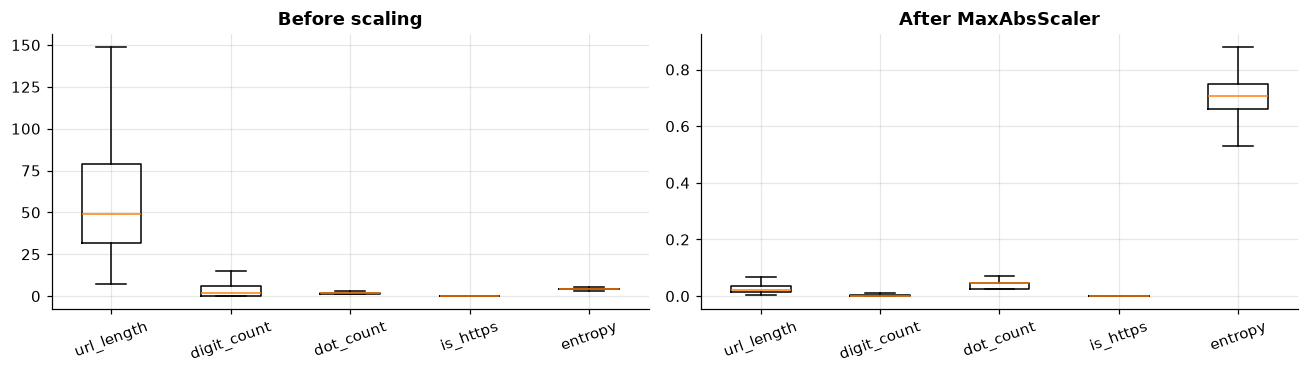

In [13]:
scaler = MaxAbsScaler().fit(Xtr_lex_raw)          # fit บน Train เท่านั้น
Xtr_lex = scaler.transform(Xtr_lex_raw)
Xte_lex = scaler.transform(Xte_lex_raw)

cols = ["url_length", "digit_count", "dot_count", "is_https", "entropy"]
idx = [FEATURE_NAMES.index(c) for c in cols]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].boxplot(Xtr_lex_raw[:20000, idx], tick_labels=cols, showfliers=False); ax[0].set_title("Before scaling")
ax[1].boxplot(Xtr_lex[:20000, idx], tick_labels=cols, showfliers=False); ax[1].set_title("After MaxAbsScaler")
for a in ax: a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** ก่อน scaling `url_length` มีค่าหลักสิบ–ร้อย ส่วน `is_https` มีค่า 0/1 หลัง scaling ทุก feature อยู่ในช่วง 0–1 ใกล้เคียงกัน

## 3.8 Feature Selection
1. **TF-IDF:** จาก n-gram ที่เป็นไปได้หลายล้านรูปแบบ เลือกเก็บเฉพาะ n-gram ที่พบอย่างน้อย 5 URL (`min_df=5`) และเก็บ 50,000 ตัวที่พบบ่อยที่สุด (`max_features`) → ตัด noise และลดขนาดโมเดล
2. **Lexical features:** วัดความสามารถแยกคลาสของแต่ละ feature ด้วย **ANOVA F-test** (`f_classif`) เพื่อดูว่า feature ไหนมีประโยชน์

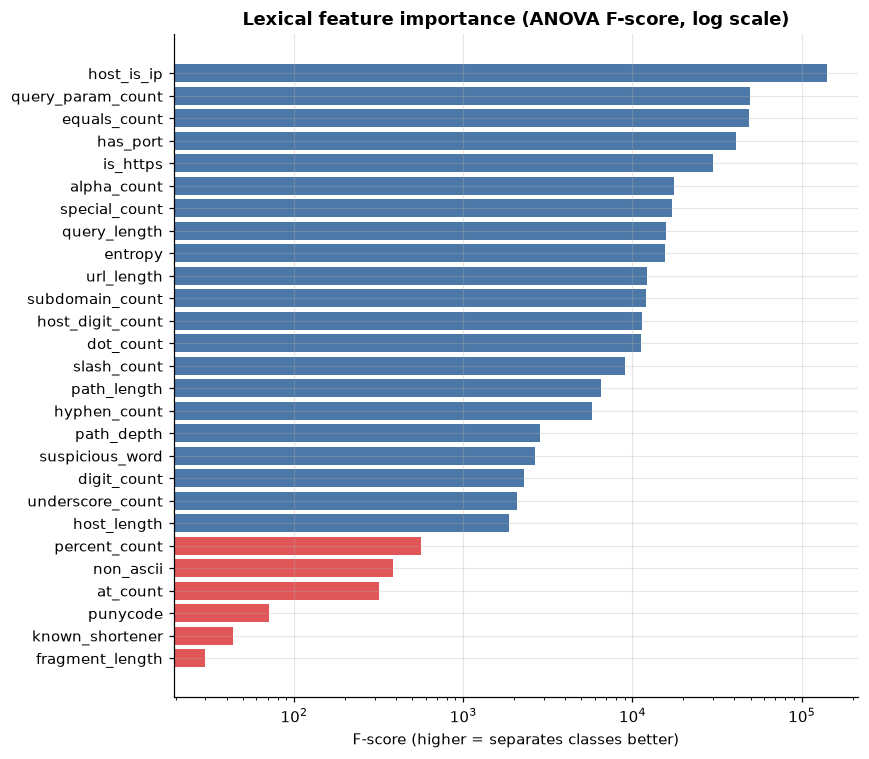

5 features ที่แยกคลาสได้ดีที่สุด: ['host_is_ip', 'query_param_count', 'equals_count', 'has_port', 'is_https']
5 features ที่แยกคลาสได้น้อยที่สุด: ['fragment_length', 'known_shortener', 'punycode', 'at_count', 'non_ascii']


In [14]:
F, p = f_classif(Xtr_lex, y_train)
fscore = pd.Series(np.nan_to_num(F), index=FEATURE_NAMES).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(fscore.index, fscore.values, color=["#E15759" if v < fscore.quantile(0.2) else "#4C78A8" for v in fscore.values])
ax.set_xscale("log"); ax.set_title("Lexical feature importance (ANOVA F-score, log scale)")
ax.set_xlabel("F-score (higher = separates classes better)")
plt.tight_layout(); plt.show()
print("5 features ที่แยกคลาสได้ดีที่สุด:", list(fscore.index[::-1][:5]))
print("5 features ที่แยกคลาสได้น้อยที่สุด:", list(fscore.index[:5]))

**📊 ผลลัพธ์:** features ที่แยกคลาสได้ดีที่สุดคือ `host_is_ip`, `query_param_count`, `equals_count`, `has_port`, `is_https`
features แถบแดง (เช่น `punycode`, `at_count`, `non_ascii`) มี F-score ต่ำเพราะพบได้น้อยมาก แต่เมื่อพบมักเป็นสัญญาณที่มีความหมาย และมีเพียง 27 ตัว
จึง **เก็บไว้ทั้งหมด** ไม่ตัดทิ้ง — ส่วนการคัดเลือก features หลักเกิดที่ TF-IDF (50,000 จากหลายล้าน n-grams)

## 3.9 Imbalanced Data
ใช้ **cost-sensitive learning**: `class_weight="balanced"` ให้น้ำหนักความผิดพลาดของแต่ละคลาส = `n_samples / (n_classes × n_class)`
คลาสที่มีน้อย (malware) จึงมีน้ำหนักมากขึ้น โดยไม่ต้องสร้างข้อมูลสังเคราะห์ และ **ไม่แตะสัดส่วนของ Test**

In [15]:
from sklearn.utils.class_weight import compute_class_weight
w = compute_class_weight("balanced", classes=np.array(LABELS), y=y_train)
pd.DataFrame({"train_rows": pd.Series(y_train).value_counts().reindex(LABELS).values, "class_weight": w}, index=LABELS)

,train_rows,class_weight
benign,342456,0.3744
defacement,76246,1.6814
phishing,75190,1.7050
malware,18916,6.7774


**📊 ผลลัพธ์:** malware ได้น้ำหนัก ~6.8 ขณะที่ benign ได้ ~0.37 (ต่างกัน ~18 เท่า) → โมเดลถูกลงโทษหนักขึ้นมากเมื่อทาย malware ผิด

---
# 4. Machine Learning Models

เปรียบเทียบ **7 โมเดล** จาก scikit-learn + Baseline โดยจัดคู่โมเดลกับ features ที่เหมาะสม:

| # | โมเดล | Features | เหตุผลที่เลือก |
|---|---|---|---|
| 0 | Dummy (majority class) | – | Baseline: ทาย benign ทุกครั้ง ใช้เป็นเส้นอ้างอิงขั้นต่ำ |
| 1 | Complement Naive Bayes | TF-IDF | เร็วมาก เหมาะกับข้อความ และทนต่อข้อมูลไม่สมดุล |
| 2 | Logistic Regression | TF-IDF | โมเดลเชิงเส้นมาตรฐานสำหรับ text classification |
| 3 | Linear SVM (LinearSVC) | TF-IDF | ทำงานดีกับข้อมูลมิติสูงแบบ sparse |
| 4 | Decision Tree | Lexical 27 | ตีความง่าย จับความสัมพันธ์ไม่เชิงเส้นได้ |
| 5 | Random Forest | Lexical 27 | Ensemble ของหลาย tree ลด overfitting ของ tree เดี่ยว |
| 6 | KNN (k=5) | Lexical 27 | ใช้ความคล้ายของโครงสร้าง URL (ฝึกบน sample 100,000 แถว เพราะ KNN ช้ามากตอนทำนาย) |
| 7 | **Hybrid LinearSVC** | TF-IDF + Lexical | รวมสองสัญญาณ: ชิ้นข้อความ + โครงสร้าง URL |

> Tree-based / KNN ใช้ lexical features เพราะทำงานไม่ดีและช้ามากกับ TF-IDF 50,000 มิติ

## 4.1 Hyperparameter Tuning ของ Hybrid LinearSVC
ใช้ **GridSearchCV + StratifiedGroupKFold (3 folds, แยก hostname)** บน sample 40,000 แถวจาก **Train เท่านั้น** (ไม่แตะ Test)
ปรับ `C` (ความแรงของ regularization) และน้ำหนักของ lexical features ใน Hybrid
ทุกขั้น (TF-IDF, scaling) อยู่ใน Pipeline เพื่อให้ fit เฉพาะ fold ที่ใช้ฝึก

Grid search 77 s


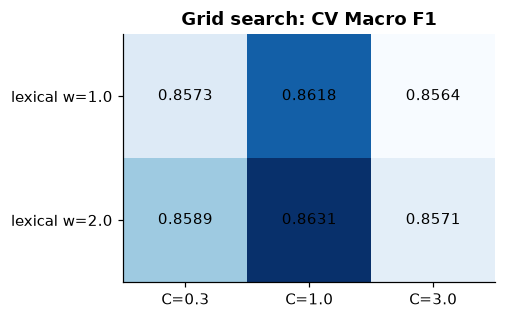

Best: C = 1.0, lexical weight = 2.0, CV Macro F1 = 0.8631


In [16]:
def hybrid_features(lexical_weight=2.0):
    return FeatureUnion([
        ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(3, 5), min_df=5, max_features=50_000,
                                  sublinear_tf=True, lowercase=False, dtype=np.float32)),
        ("lexical", Pipeline([("extract", FunctionTransformer(extract_lexical_features)),
                              ("scale", MaxAbsScaler())])),
    ], transformer_weights={"tfidf": 1.0, "lexical": lexical_weight})

tune_idx, _ = train_test_split(np.arange(len(train)), train_size=min(40_000, len(train) - 1),
                               stratify=y_train, random_state=RANDOM_STATE)
tune = train.iloc[tune_idx]
search = GridSearchCV(
    Pipeline([("features", hybrid_features()),
              ("clf", LinearSVC(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE))]),
    param_grid={"clf__C": [0.3, 1.0, 3.0], "features__transformer_weights": [
        {"tfidf": 1.0, "lexical": 1.0}, {"tfidf": 1.0, "lexical": 2.0}]},
    scoring="f1_macro", cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1)
t0 = time.perf_counter()
search.fit(tune.url.to_numpy(dtype=object), tune.type.to_numpy(), groups=tune.host.where(tune.host != "", tune.url))
print(f"Grid search {time.perf_counter()-t0:.0f} s")

cv = pd.DataFrame(search.cv_results_)
cv["C"] = cv["param_clf__C"]; cv["lexical_weight"] = cv["param_features__transformer_weights"].map(lambda d: d["lexical"])
pivot = cv.pivot(index="lexical_weight", columns="C", values="mean_test_score")
fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(pivot.values, cmap="Blues")
ax.set_xticks(range(len(pivot.columns)), [f"C={c}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)), [f"lexical w={w}" for w in pivot.index])
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.4f}", ha="center", va="center")
ax.set_title("Grid search: CV Macro F1"); ax.grid(False)
plt.tight_layout(); plt.show()
BEST_C = search.best_params_["clf__C"]
BEST_W = search.best_params_["features__transformer_weights"]["lexical"]
print(f"Best: C = {BEST_C}, lexical weight = {BEST_W}, CV Macro F1 = {search.best_score_:.4f}")

## 4.2 ฝึกทุกโมเดลบน Train และทำนาย Test

In [17]:
Xtr_hybrid = sparse.hstack([Xtr_tfidf, sparse.csr_matrix(Xtr_lex * BEST_W)]).tocsr()
Xte_hybrid = sparse.hstack([Xte_tfidf, sparse.csr_matrix(Xte_lex * BEST_W)]).tocsr()

knn_idx, _ = train_test_split(np.arange(len(train)), train_size=min(100_000, len(train) - 1),
                              stratify=y_train, random_state=RANDOM_STATE)

MODELS = {
    "Dummy (majority)":    ("none",    DummyClassifier(strategy="most_frequent")),
    "ComplementNB":        ("tfidf",   ComplementNB(alpha=0.1)),
    "LogisticRegression":  ("tfidf",   LogisticRegression(C=10, class_weight="balanced", max_iter=300, random_state=RANDOM_STATE)),
    "LinearSVC":           ("tfidf",   LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)),
    "DecisionTree":        ("lexical", DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE)),
    "RandomForest":        ("lexical", RandomForestClassifier(n_estimators=100, min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)),
    "KNN (k=5)":           ("lexical", KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    "Hybrid LinearSVC":    ("hybrid",  LinearSVC(C=BEST_C, class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)),
}
FEATURES = {"none": (np.zeros((len(train), 1)), np.zeros((len(test), 1))),
            "tfidf": (Xtr_tfidf, Xte_tfidf), "lexical": (Xtr_lex, Xte_lex), "hybrid": (Xtr_hybrid, Xte_hybrid)}

rows, predictions, fitted = [], {}, {}
for name, (feat, model) in MODELS.items():
    Xtr, Xte = FEATURES[feat]
    ytr = y_train
    if name.startswith("KNN"):
        Xtr, ytr = Xtr[knn_idx], y_train[knn_idx]
    t0 = time.perf_counter(); model.fit(Xtr, ytr); fit_s = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = model.predict(Xte); pred_s = time.perf_counter() - t0
    predictions[name], fitted[name] = pred, model
    rows.append({"model": name, "features": feat, "train_rows": len(ytr),
                 "accuracy": accuracy_score(y_test, pred),
                 "precision_macro": precision_score(y_test, pred, average="macro", zero_division=0),
                 "recall_macro": recall_score(y_test, pred, average="macro", zero_division=0),
                 "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
                 "train_time_s": fit_s, "predict_time_s": pred_s})
    print(f"✓ {name:<20} Macro F1 = {rows[-1]['f1_macro']:.4f}   fit {fit_s:6.1f}s")

results = pd.DataFrame(rows).set_index("model").sort_values("f1_macro", ascending=False)
results

✓ Dummy (majority)     Macro F1 = 0.2002   fit    0.3s


✓ ComplementNB         Macro F1 = 0.7826   fit    1.4s


✓ LogisticRegression   Macro F1 = 0.8830   fit   32.9s


✓ LinearSVC            Macro F1 = 0.9141   fit   44.8s


✓ DecisionTree         Macro F1 = 0.7974   fit    5.2s


✓ RandomForest         Macro F1 = 0.8751   fit   18.1s


✓ KNN (k=5)            Macro F1 = 0.8508   fit    0.2s


✓ Hybrid LinearSVC     Macro F1 = 0.9154   fit   91.0s


,features,train_rows,accuracy,precision_macro,recall_macro,f1_macro,train_time_s,predict_time_s
model,,,,,,,,
Hybrid LinearSVC,hybrid,512808,0.9425,0.9228,0.9121,0.9154,91.0129,0.0969
LinearSVC,tfidf,512808,0.9421,0.9220,0.9101,0.9141,44.7559,0.0814
LogisticRegression,tfidf,512808,0.9066,0.8716,0.9070,0.8830,32.9490,0.0492
RandomForest,lexical,512808,0.9113,0.8893,0.8680,0.8751,18.0651,0.3546
KNN (k=5),lexical,100000,0.8989,0.8645,0.8414,0.8508,0.2085,12.9852
DecisionTree,lexical,512808,0.8529,0.7649,0.8483,0.7974,5.1890,0.0188
ComplementNB,tfidf,512808,0.8535,0.8078,0.7719,0.7826,1.3663,0.0786
Dummy (majority),none,512808,0.6678,0.1670,0.2500,0.2002,0.2579,0.0008


---
# 5. Model Evaluation

### เลือก Metric อย่างไร
| Metric | ความหมาย | ใช้ในงานนี้เพราะ |
|---|---|---|
| **Accuracy** | สัดส่วนที่ทายถูกทั้งหมด | ดูภาพรวม แต่หลอกได้เมื่อข้อมูลไม่สมดุล |
| **Precision** | ที่ทายว่าเป็นคลาส c ถูกจริงกี่ % | ถ้าต่ำ = เตือนผิด (false alarm) บ่อย |
| **Recall** | คลาส c จริง ถูกจับได้กี่ % | สำคัญที่สุดกับ phishing/malware — พลาด = ผู้ใช้โดนโจมตี |
| **F1-score** | ค่าเฉลี่ยฮาร์มอนิกของ Precision กับ Recall | สมดุลระหว่างเตือนผิดกับพลาด |
| **Macro F1** ⭐ | F1 เฉลี่ยทุกคลาสเท่า ๆ กัน | **เกณฑ์หลัก** เพราะให้คลาสเล็ก (malware) มีความสำคัญเท่าคลาสใหญ่ |
| **Confusion Matrix** | ตารางจริง vs ทาย | ดูว่าสับสนระหว่างคลาสไหน |

## 5.1 เปรียบเทียบคะแนนทุกโมเดล

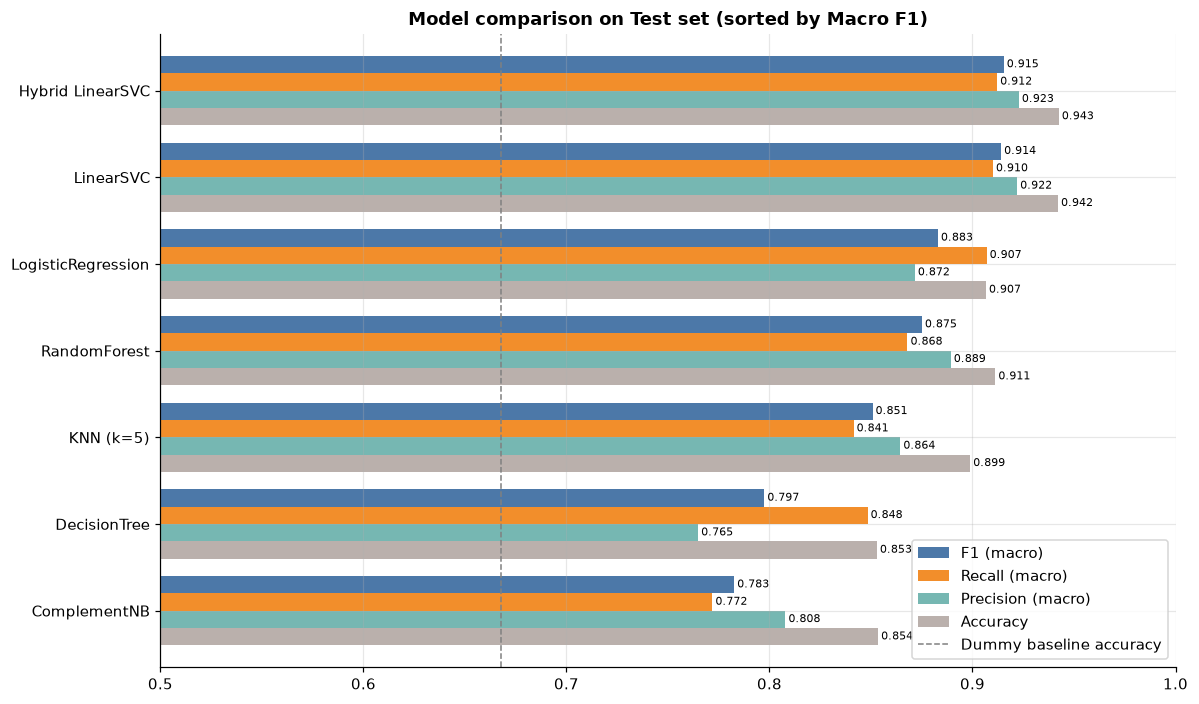

In [18]:
plot_df = results.drop(index="Dummy (majority)")[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].iloc[::-1]
ax = plot_df.plot.barh(figsize=(11, 6.5), width=0.8, color=["#BAB0AC", "#76B7B2", "#F28E2B", "#4C78A8"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=7, padding=2)
handles, _ = ax.get_legend_handles_labels()
dummy_line = ax.axvline(results.loc["Dummy (majority)", "accuracy"], ls="--", c="grey", lw=1)
ax.set_xlim(0.5, 1.0); ax.set_title("Model comparison on Test set (sorted by Macro F1)"); ax.set_ylabel("")
ax.legend(handles[::-1] + [dummy_line],
          ["F1 (macro)", "Recall (macro)", "Precision (macro)", "Accuracy", "Dummy baseline accuracy"], loc="lower right")
plt.tight_layout(); plt.show()

## 5.2 Recall และ F1 รายคลาส
Recall ของ **phishing** และ **malware** คือสิ่งที่ผู้ใช้สนใจที่สุด (พลาด = ปล่อยลิงก์อันตรายผ่าน)

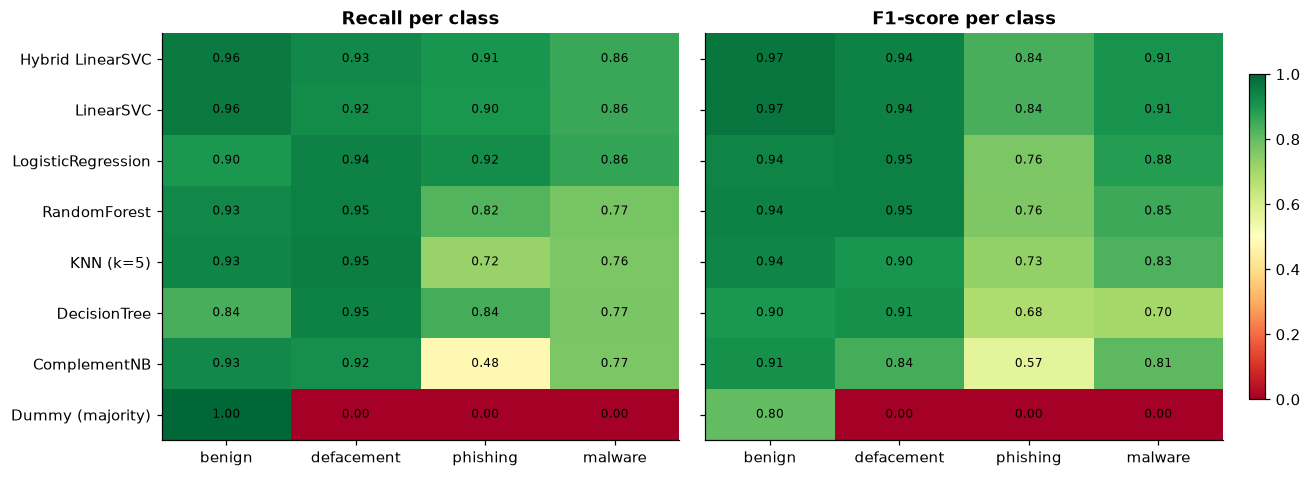

In [19]:
per_class = {}
for name, pred in predictions.items():
    rep = classification_report(y_test, pred, labels=LABELS, output_dict=True, zero_division=0)
    per_class[name] = {**{f"recall_{c}": rep[c]["recall"] for c in LABELS}, **{f"f1_{c}": rep[c]["f1-score"] for c in LABELS}}
per_class = pd.DataFrame(per_class).T.loc[results.index]

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"wspace": 0.05})
for a, prefix, title in [(ax[0], "recall_", "Recall per class"), (ax[1], "f1_", "F1-score per class")]:
    m = per_class[[prefix + c for c in LABELS]].values
    im = a.imshow(m, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    a.set_xticks(range(4), LABELS); a.set_yticks(range(len(per_class)), per_class.index)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            a.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center", fontsize=8)
    a.set_title(title); a.grid(False)
ax[1].set_yticklabels([])
fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
plt.show()

## 5.3 Macro F1 vs เวลาที่ใช้ (ฝึก + ทำนาย Test)

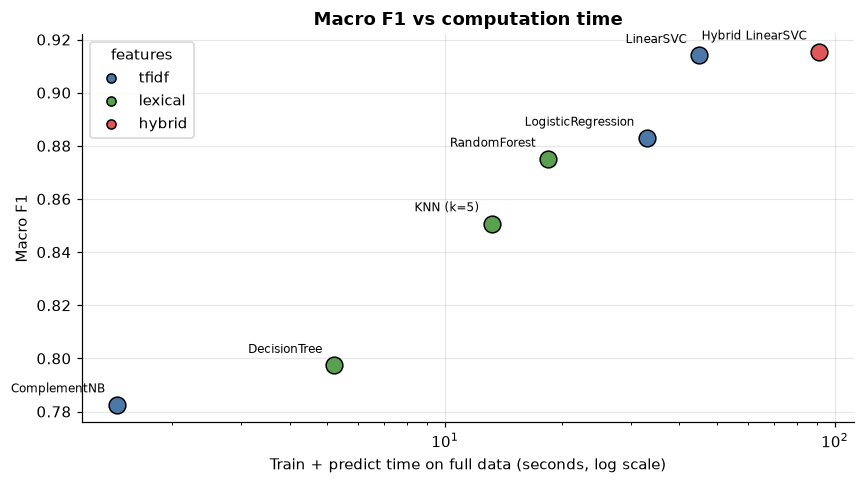

In [20]:
r = results.drop(index="Dummy (majority)")
fig, ax = plt.subplots(figsize=(8, 4.5))
palette = {"tfidf": "#4C78A8", "lexical": "#59A14F", "hybrid": "#E15759"}
for name, row in r.iterrows():
    total = row.train_time_s + row.predict_time_s
    ax.scatter(total, row.f1_macro, s=120, color=palette[row.features], edgecolor="black", zorder=3)
    ax.annotate(name, (total, row.f1_macro), textcoords="offset points", xytext=(-8, 8), fontsize=8, ha="right")
ax.set_xscale("log"); ax.set_xlabel("Train + predict time on full data (seconds, log scale)"); ax.set_ylabel("Macro F1")
ax.set_title("Macro F1 vs computation time")
for k, v in palette.items():
    ax.scatter([], [], color=v, label=k, edgecolor="black")
ax.legend(title="features")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** LinearSVC/Hybrid ได้คะแนนสูงสุดโดยใช้เวลาเพียง 1–2 นาที ส่วน KNN ฝึกเร็ว (แค่เก็บข้อมูล) แต่ **ทำนายช้า** เพราะต้องเทียบกับข้อมูลฝึกทุกแถว

## 5.4 Confusion Matrix: โมเดลที่ดีที่สุด 2 อันดับแรก

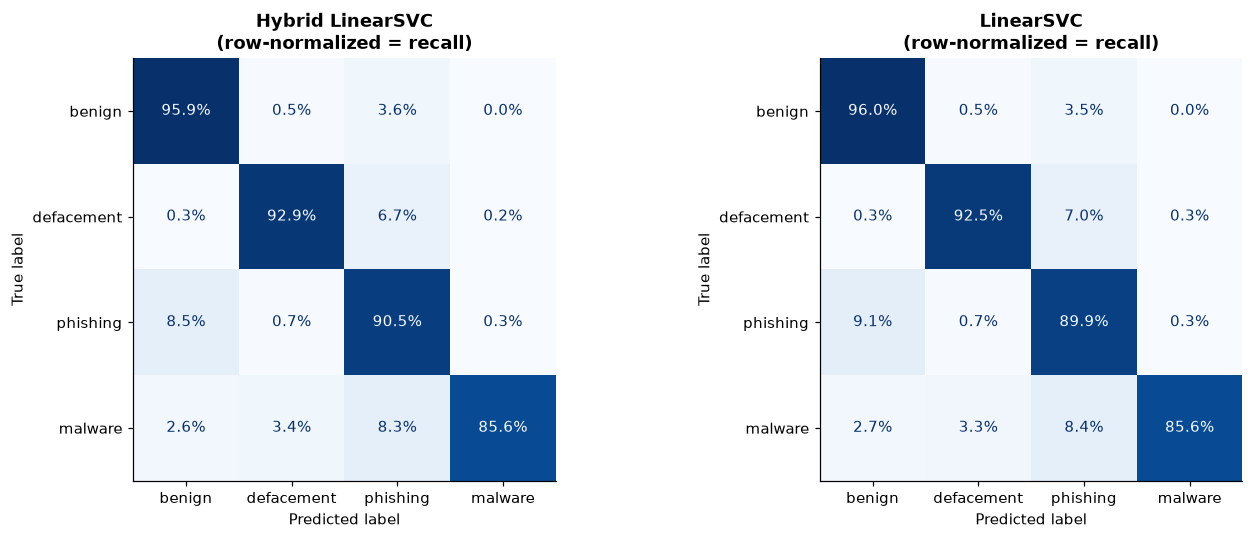

Classification report — Hybrid LinearSVC


              precision    recall  f1-score   support

      benign     0.9788    0.9586    0.9686     85615
  defacement     0.9612    0.9288    0.9447     19062
    phishing     0.7818    0.9050    0.8389     18797
     malware     0.9696    0.8562    0.9094      4729

    accuracy                         0.9425    128203
   macro avg     0.9228    0.9121    0.9154    128203
weighted avg     0.9469    0.9425    0.9438    128203



In [21]:
BEST = results.index[0]
SECOND = results.index[1]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, name in zip(ax, [BEST, SECOND]):
    cm = confusion_matrix(y_test, predictions[name], labels=LABELS, normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=a, cmap="Blues", values_format=".1%", colorbar=False)
    a.set_title(f"{name}\n(row-normalized = recall)"); a.grid(False)
plt.tight_layout(); plt.show()

print(f"Classification report — {BEST}")
print(classification_report(y_test, predictions[BEST], labels=LABELS, digits=4))

## 5.5 วิเคราะห์ข้อผิดพลาดของโมเดลที่ดีที่สุด
ความผิดพลาดที่อันตรายที่สุดคือ **phishing/malware ถูกทายว่า benign** (ลิงก์อันตรายหลุดผ่าน)

In [22]:
err = test[["url", "type"]].copy(); err["prediction"] = predictions[BEST]
danger = err.type.isin(["phishing", "malware"])
summary = pd.Series({
    "phishing → benign (หลุด)": int(((err.type == "phishing") & (err.prediction == "benign")).sum()),
    "malware → benign (หลุด)": int(((err.type == "malware") & (err.prediction == "benign")).sum()),
    "benign → เตือนผิด": int(((err.type == "benign") & (err.prediction != "benign")).sum()),
    "อันตราย ถูกเตือน (ทายเป็นคลาสอันตรายใดก็ได้)": f"{(err.prediction[danger] != 'benign').mean():.2%}",
})
display(summary.to_frame("count"))
print("ตัวอย่าง phishing ที่โมเดลทายว่า benign:")
display(err[(err.type == "phishing") & (err.prediction == "benign")].sample(8, random_state=1).assign(url=lambda d: d.url.map(defang)))

,count
phishing → benign (หลุด),1601
malware → benign (หลุด),124
benign → เตือนผิด,3546
อันตราย ถูกเตือน (ทายเป็นคลาสอันตรายใดก็ได้),92.67%


ตัวอย่าง phishing ที่โมเดลทายว่า benign:


,url,type,prediction
125495,thekonst[.]net/centericq,phishing,benign
121741,en[.]wikipedia[.]org/wiki/PA-RISC_family,phishing,benign
127328,gamereport[.]com/tgr23/kingoftheelves[.]shtml,phishing,benign
120439,ohioline[.]osu[.]edu/hyg-fact/5000/5541[.]html,phishing,benign
126833,lightfantastic[.]org/eye,phishing,benign
124875,public[.]kitware[.]com/Dart/,phishing,benign
126709,osteele[.]com/sources/python[.]html,phishing,benign
124406,oreilly[.]com/catalog/9780596523695/,phishing,benign


## 5.6 ทดสอบกับ URL จริงที่รู้จัก (Sanity check)
คะแนนบน Test สูง แต่ Test มาจากแหล่งเดียวกับ Train จึงลองป้อน URL ที่รู้คำตอบ และเขียน URL เดียวกันหลายรูปแบบ

In [23]:
best_model = fitted[BEST]
def predict_texts(texts):
    t = np.array(texts, dtype=object)
    Xt = tfidf.transform(t); Xl = scaler.transform(extract_lexical_features(t))
    feats = {"tfidf": Xt, "lexical": Xl, "hybrid": sparse.hstack([Xt, sparse.csr_matrix(Xl * BEST_W)]).tocsr()}
    return best_model.predict(feats[MODELS[BEST][0]])

known = ["en.wikipedia.org/wiki/Machine_learning", "https://en.wikipedia.org/wiki/Machine_learning",
         "google.com/search?q=weather", "google.com", "https://www.google.com/",
         "youtube.com/watch?v=dQw4w9WgXcQ", "github.com/scikit-learn/scikit-learn",
         "paypal.com.secure-login.verify-account.xyz/signin?id=123", "http://192.168.10.5/files/setup.exe"]
expected = ["benign"] * 7 + ["phishing", "malware"]
sanity = pd.DataFrame({"url": [defang(u) for u in known], "expected": expected, "prediction": predict_texts(known)})
sanity["correct"] = np.where(sanity.expected == sanity.prediction, "✅", "❌")
sanity

,url,expected,prediction,correct
0,en[.]wikipedia[.]org/wiki/Machine_learning,benign,benign,✅
1,hxxps://en[.]wikipedia[.]org/wiki/Machine_lear...,benign,phishing,❌
2,google[.]com/search?q=weather,benign,benign,✅
3,google[.]com,benign,phishing,❌
4,hxxps://www[.]google[.]com/,benign,phishing,❌
5,youtube[.]com/watch?v=dQw4w9WgXcQ,benign,benign,✅
6,github[.]com/scikit-learn/scikit-learn,benign,phishing,❌
7,paypal[.]com[.]secure-login[.]verify-account[....,phishing,phishing,✅
8,hxxp://192[.]168[.]10[.]5/files/setup[.]exe,malware,malware,✅


**📊 ผลลัพธ์ (ข้อจำกัดสำคัญ):** ลิงก์อันตรายตัวอย่าง (สร้างขึ้นเอง) ถูกจับได้ แต่ **URL ปกติบางรูปแบบถูกทายเป็น phishing**
- `en.wikipedia.org/wiki/...` → benign ✅ แต่ **เติม `https://` เข้าไปอย่างเดียว** กลายเป็น phishing ❌
- หน้าแรกสั้น ๆ เช่น `google.com` → phishing ❌ เพราะใน Dataset URL phishing จำนวนมากเป็นโดเมนสั้น ๆ ส่วน benign เกือบทั้งหมดเป็น URL ยาวที่มี path

สาเหตุคือ **dataset bias** ที่พบในหัวข้อ 3.4 — รูปแบบการเขียน URL ผูกกับแหล่งที่เก็บข้อมูลของแต่ละคลาส
เราทดลองแก้โดยตัด `http(s)://`, `www.` และ `/` ท้าย URL ออกก่อนฝึก (normalize) ผลคือ Macro F1 ลดจาก ~0.915 เหลือ ~0.850
และ `google.com` ก็ยังถูกทายเป็น phishing จึง **คงโมเดลเดิมไว้** และรายงานข้อจำกัดนี้ในหัวข้อ Discussion

## 5.7 เลือกโมเดลสุดท้าย
เลือกด้วย **Macro F1 บน Test** เป็นหลัก แล้วดู Recall ของ phishing/malware และเวลาทำนายประกอบ

In [24]:
cmp = results.loc[[BEST, SECOND], ["accuracy", "precision_macro", "recall_macro", "f1_macro", "train_time_s", "predict_time_s"]]
cmp = cmp.join(per_class[["recall_phishing", "recall_malware"]])
display(cmp.T)
print(f"🏆 โมเดลสุดท้าย: {BEST}")

model,Hybrid LinearSVC,LinearSVC
accuracy,0.9425,0.9421
precision_macro,0.9228,0.9220
recall_macro,0.9121,0.9101
f1_macro,0.9154,0.9141
train_time_s,91.0129,44.7559
predict_time_s,0.0969,0.0814
recall_phishing,0.9050,0.8994
recall_malware,0.8562,0.8562


🏆 โมเดลสุดท้าย: Hybrid LinearSVC


**เหตุผลที่เลือก Hybrid LinearSVC เป็นโมเดลสุดท้าย**
1. **Macro F1 สูงที่สุด (0.9154)** และ Accuracy สูงสุด (94.25%) — ทำได้ดีสม่ำเสมอทั้ง 4 คลาส ไม่ใช่แค่คลาสใหญ่
2. **Recall ของ phishing สูงกว่า LinearSVC ธรรมดา** (0.905 vs 0.899) โดย recall ของ malware เท่ากัน — ตรงกับเป้าหมายที่ต้องการลดลิงก์อันตรายที่หลุดผ่าน
   แต่ส่วนต่าง Macro F1 กับ LinearSVC มีเพียง ~0.001 จึงสรุปได้ว่า **lexical features ช่วยเพิ่มได้เล็กน้อย** ส่วนพลังหลักมาจาก TF-IDF + LinearSVC
3. **รวมจุดแข็งของสองแนวทาง** — TF-IDF จับ "ชิ้นข้อความ" ส่วน lexical features จับ "โครงสร้าง" (ความยาว, IP, จำนวนจุด)
   ดีกว่าโมเดล tree/KNN ที่ใช้ lexical อย่างเดียวชัดเจน (Macro F1 ≤ 0.875)
4. **เร็ว** — ฝึกบนข้อมูลครึ่งล้านแถวได้ในระดับนาที และทำนาย 1 URL ในระดับมิลลิวินาที เหมาะกับ Web App
5. **ไฟล์โมเดลเล็ก (~2 MB)** เมื่อเทียบกับ Random Forest / KNN ที่ต้องเก็บ tree จำนวนมาก หรือเก็บข้อมูล Train ทั้งหมด

ข้อสังเกต: ในกลุ่ม lexical features Random Forest ดีที่สุด (0.875) แต่ยังต่ำกว่าโมเดลที่ใช้ TF-IDF ส่วน ComplementNB เร็วที่สุดแต่จับ phishing ได้เพียง 48%

## 5.8 N-grams ที่มีผลต่อการทำนายมากที่สุด (ตีความโมเดล)

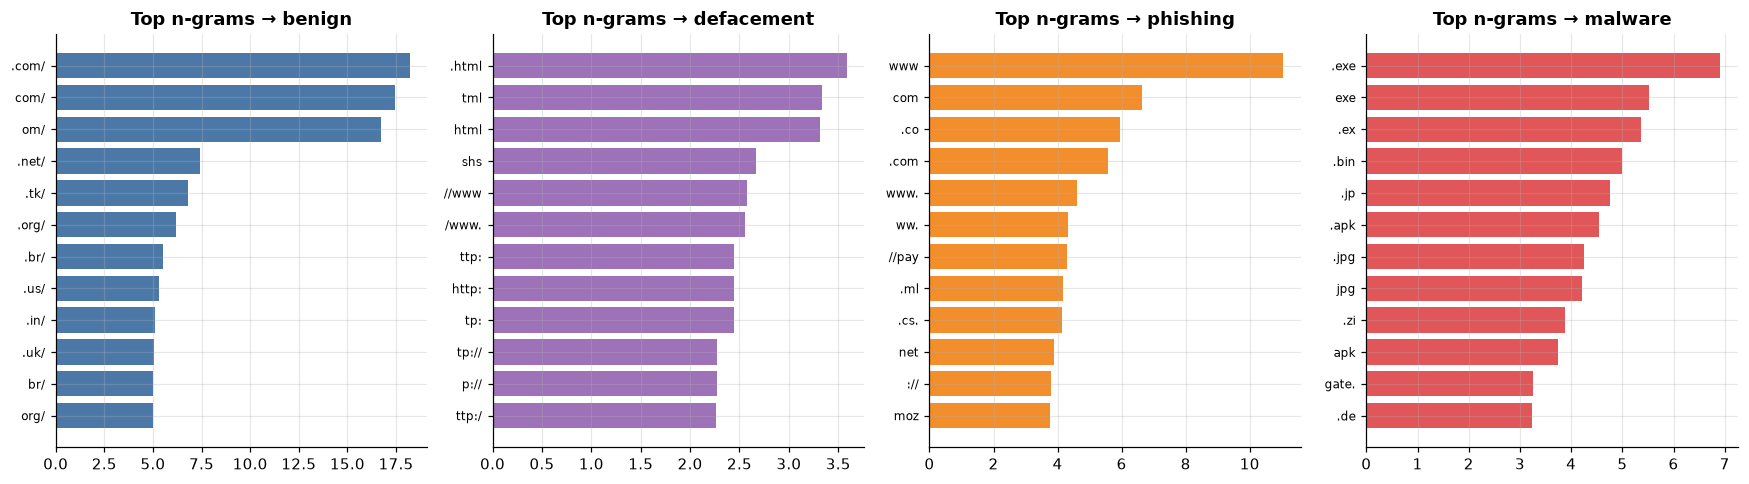

In [25]:
svc = fitted["Hybrid LinearSVC"]
vocab = np.array(tfidf.get_feature_names_out())
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for a, cls in zip(axes, LABELS):
    k = list(svc.classes_).index(cls)
    coef = svc.coef_[k, :len(vocab)]
    top = np.argsort(coef)[-12:]
    a.barh([repr(v)[1:-1] for v in vocab[top]], coef[top], color=COLORS[cls])
    a.set_title(f"Top n-grams → {cls}"); a.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** บางรูปแบบสมเหตุสมผล เช่น malware ↔ นามสกุลไฟล์ `.exe`, `.bin`, `.apk`; phishing ↔ `//pay` (paypal ปลอม); defacement ↔ `.html`
แต่ n-gram ที่มีน้ำหนักสูงหลายตัว **ยืนยัน dataset bias** จากหัวข้อ 3.4 และ 5.6: `www` เป็นสัญญาณอันดับ 1 ของ phishing, `http:` / `//www` เป็นสัญญาณของ defacement
และ `.com/` เป็นสัญญาณของ benign — เป็นเรื่องรูปแบบการเขียน URL ไม่ใช่ความอันตรายจริง

## 5.9 บันทึกโมเดลสำหรับ Web App
รวม TF-IDF + lexical scaler + classifier ที่ฝึกแล้วเป็น **Pipeline เดียว** ที่รับ "ข้อความ URL" แล้วคืนชื่อคลาส
และตรวจว่าผลทำนายตรงกับตอนประเมินทุกแถว

In [26]:
lexical_pipe = Pipeline([("extract", FunctionTransformer(extract_lexical_features)), ("scale", scaler)])
FEATURE_STEP = {
    "tfidf": tfidf,
    "lexical": lexical_pipe,
    "hybrid": FeatureUnion([("tfidf", tfidf), ("lexical", lexical_pipe)],
                           transformer_weights={"tfidf": 1.0, "lexical": BEST_W}),
}
final_model = Pipeline([("features", FEATURE_STEP[MODELS[BEST][0]]), ("clf", fitted[BEST])])

check = final_model.predict(X_test_text[:20_000])
assert (check == predictions[BEST][:20_000]).all(), "pipeline ให้ผลต่างจากตอนประเมิน"

joblib.dump(final_model, "models/url_classifier.joblib", compress=3)
meta = {"model": BEST, "C": BEST_C, "lexical_weight": BEST_W, "labels": LABELS,
        "train_rows": len(train), "test_rows": len(test),
        "test_scores": results.loc[BEST, ["accuracy", "precision_macro", "recall_macro", "f1_macro"]].round(4).to_dict(),
        "comparison": results[["f1_macro", "accuracy"]].round(4).to_dict(orient="index")}
pd.Series(meta).to_json("models/model_info.json", force_ascii=False, indent=2)
print(f"บันทึก models/url_classifier.joblib ({Path('models/url_classifier.joblib').stat().st_size/1e6:.1f} MB)")

# ทดสอบโหลดกลับและทำนายเหมือนที่ Web App ทำ
loaded = joblib.load("models/url_classifier.joblib")
demo = ["en.wikipedia.org/wiki/Machine_learning", "http://paypal.com.secure-login.verify-account.xyz/signin?id=123",
        "http://192.168.10.5/files/setup.exe", "http://example.com/index.php?option=com_content&view=article&id=5"]
pd.DataFrame({"url": [defang(u) for u in demo], "prediction": loaded.predict(np.array(demo, dtype=object))})

บันทึก models/url_classifier.joblib (2.0 MB)


,url,prediction
0,en[.]wikipedia[.]org/wiki/Machine_learning,benign
1,hxxp://paypal[.]com[.]secure-login[.]verify-ac...,phishing
2,hxxp://192[.]168[.]10[.]5/files/setup[.]exe,malware
3,hxxp://example[.]com/index[.]php?option=com_co...,defacement


---
# 6. Web Application

พัฒนา Web App **1 หน้า** ด้วย **Streamlit** (ไฟล์ `app.py`) ใช้โมเดล `models/url_classifier.joblib` ที่บันทึกด้านบน

| องค์ประกอบที่โจทย์กำหนด | ในแอป |
|---|---|
| ช่องกรอกข้อมูล | ช่องกรอก URL + ปุ่มตัวอย่าง URL |
| ปุ่ม Predict | ปุ่ม **🔍 Predict** |
| แสดงผลลัพธ์การทำนาย | การ์ดผลลัพธ์แสดงคลาสพร้อมสีตามระดับความเสี่ยง |
| แสดงความหมายของผลลัพธ์ | คำอธิบายของคลาส + คำแนะนำว่าควรทำอย่างไร + กราฟคะแนนของแต่ละคลาส |

**ขั้นตอนการทำงาน:** ผู้ใช้กรอก URL → ตรวจ input (ว่าง/control characters) → Pipeline แปลงเป็น TF-IDF + lexical features → LinearSVC ทำนาย → แสดงผล
แอป **ไม่เปิดเว็บไซต์ที่กรอก** จึงปลอดภัยต่อการทดสอบลิงก์อันตราย

**วิธีรัน**
```bash
pip install -r requirements.txt
streamlit run app.py
```

---
# 7. Discussion

### ✅ จุดเด่นของโมเดล
- **Accuracy 94.25% / Macro F1 0.915** บน Test 128,203 URLs ที่ **แยก hostname** จาก Train (ไม่ใช่การสุ่มธรรมดาที่ทำให้คะแนนสูงเกินจริง)
- ลิงก์อันตรายจริง (phishing + malware) **ถูกเตือน 92.7%** และ defacement มี precision 0.96
- ดีกว่า Baseline (Dummy, Macro F1 0.20) และดีกว่าอีก 6 โมเดลที่เปรียบเทียบ
- ใช้เพียงข้อความ URL → **เร็ว ปลอดภัย** ไม่ต้องเปิดเว็บไซต์; โมเดลเล็ก ~2 MB ทำนาย 1 URL ในระดับมิลลิวินาที
- โมเดลเชิงเส้น **ตีความได้** จาก n-grams ที่มีน้ำหนักสูง (หัวข้อ 5.8)

### ⚠️ จุดอ่อน
- **Dataset bias / shortcut learning** — โมเดลใช้ "รูปแบบการเขียน URL" (มี `http://`, `www.` หรือไม่) เป็นสัญญาณสำคัญ ซึ่งผูกกับแหล่งเก็บข้อมูล ไม่ใช่ความอันตรายจริง
  ทำให้ URL ปกติบางรูปแบบ เช่น `https://www.google.com/` ถูกทายเป็น phishing (หัวข้อ 5.6) — **ความแม่นยำกับ URL ทั่วไปในชีวิตจริงจึงต่ำกว่าคะแนนบน Test**
- **Phishing ยากที่สุด** — Precision 0.78 / Recall 0.905; phishing 1,601 URL หลุดเป็น benign และ benign 3,546 URL (~4.1%) ถูกเตือนผิด
- Malware recall 0.856 — มี malware 124 URL ที่หลุดเป็น benign
- LinearSVC **ไม่ให้ค่าความน่าจะเป็น** — คะแนนที่แสดงในแอปเป็น decision score ใช้เปรียบเทียบระหว่างคลาสได้ แต่ไม่ใช่ % ความมั่นใจ
- ดูเฉพาะข้อความ ไม่ได้ดูเนื้อหาเว็บ อายุโดเมน หรือ SSL certificate

### 🧩 ปัญหาที่พบระหว่างทำโครงงาน
1. **ข้อมูลซ้ำและ label ขัดแย้ง** — แถวซ้ำ 10,066 แถว และ URL เดียวกันมีหลาย label (เช่น หน้า Wikipedia ถูกติดทั้ง benign และ phishing) ต้องทำความสะอาดก่อน
2. **Data leakage จาก hostname** — ถ้าสุ่มแบ่งธรรมดา URL จากเว็บเดียวกันอยู่ทั้ง Train/Test จึงเปลี่ยนมาใช้ StratifiedGroupKFold ตาม hostname
3. **ข้อมูลไม่สมดุล** — malware มีเพียง ~5% จึงใช้ class_weight และวัดด้วย Macro F1
4. **ขนาดข้อมูลใหญ่** — KNN ทำนายช้ามากกับข้อมูลเต็ม จึงจำกัดข้อมูลฝึกของ KNN ไว้ 100,000 แถว; Tree-based ไม่เหมาะกับ TF-IDF 50,000 มิติ
5. **Dataset bias** — พบตอนทดสอบกับ URL จริง (หัวข้อ 5.6) ทดลองแก้ด้วยการ normalize URL แต่ Macro F1 ลดเหลือ ~0.85 และยังไม่แก้ปัญหาหน้าแรกของเว็บ
   แสดงว่าต้องแก้ที่ **ข้อมูล** มากกว่าที่โมเดล

### 🚀 แนวทางพัฒนาในอนาคต
- **เพิ่มข้อมูล benign ที่หลากหลาย** (เช่น หน้าแรกของเว็บยอดนิยม ทั้งแบบมีและไม่มี `https://www.`) และรวม Dataset จากหลายแหล่ง/หลายช่วงเวลา เพื่อลด bias
- ทำ **probability calibration** (`CalibratedClassifierCV`) เพื่อแสดง % ความมั่นใจ และปรับ threshold ให้จับ phishing ได้มากขึ้น
- เพิ่ม features ที่ไม่ใช่ข้อความ เช่น อายุโดเมน, WHOIS, SSL certificate, อันดับความนิยมของโดเมน
- ทดสอบกับ Dataset ภายนอก (เช่น PhishTank ล่าสุด) เพื่อวัดความสามารถกับข้อมูลใหม่จริง

---
# 8. References
1. Siddhartha, M. *Malicious URLs Dataset*. Kaggle. https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset
2. Mamun, M. S. I., et al. (2016). *Detecting Malicious URLs Using Lexical Analysis*. NSS 2016 (ISCX-URL2016). https://www.unb.ca/cic/datasets/url-2016.html
3. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, 2825–2830. https://scikit-learn.org
4. scikit-learn documentation — [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html), [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html), [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html), [Classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)
5. Streamlit documentation. https://docs.streamlit.io
6. PhishTank. https://phishtank.org